In [1]:
import numpy as np
import joblib
import mlflow
import mlflow.sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score,
                             f1_score,
                             precision_score,
                             recall_score)
import warnings
warnings.filterwarnings('ignore')

# Load processed data — no repetition needed
X_train_bal = np.load('data/processed/X_train_bal.npy')
y_train_bal = np.load('data/processed/y_train_bal.npy')
X_test      = np.load('data/processed/X_test.npy')
y_test      = np.load('data/processed/y_test.npy')
feature_names = joblib.load('models/feature_names.pkl')

print(f"X_train_bal: {X_train_bal.shape}")
print(f"y_train_bal: {y_train_bal.shape}")
print(f"X_test:      {X_test.shape}")
print(f"y_test:      {y_test.shape}")
print("Data loaded successfully ✅")

X_train_bal: (398040, 31)
y_train_bal: (398040,)
X_test:      (85443, 31)
y_test:      (85443,)
Data loaded successfully ✅


In [2]:
mlflow.set_experiment("fraud_detection")

with mlflow.start_run(run_name="random_forest_v1"):

    # Define model
    rf_model = RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        n_jobs=-1
    )

    # Log parameters
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("min_samples_split", 10)

    # Train
    print("Training Random Forest...")
    rf_model.fit(X_train_bal, y_train_bal)
    print("Training done!")

    # Predict
    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    # Metrics
    auc  = roc_auc_score(y_test, y_prob)
    f1   = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    # Log metrics
    mlflow.log_metric("auc_roc", auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)

    # Log model
    mlflow.sklearn.log_model(rf_model, "model")

    # Print
    print("\n" + "="*50)
    print("RANDOM FOREST RESULTS")
    print("="*50)
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Normal', 'Fraud']))

    rf_run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID: {rf_run_id}")


Training Random Forest...
Training done!


2026/06/09 11:31:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 11:31:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



RANDOM FOREST RESULTS
AUC-ROC:   0.9783
F1 Score:  0.6186
Precision: 0.5000
Recall:    0.8108

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.50      0.81      0.62       148

    accuracy                           1.00     85443
   macro avg       0.75      0.90      0.81     85443
weighted avg       1.00      1.00      1.00     85443


MLflow Run ID: a0e0064326714602abd09e6b9b1908a1


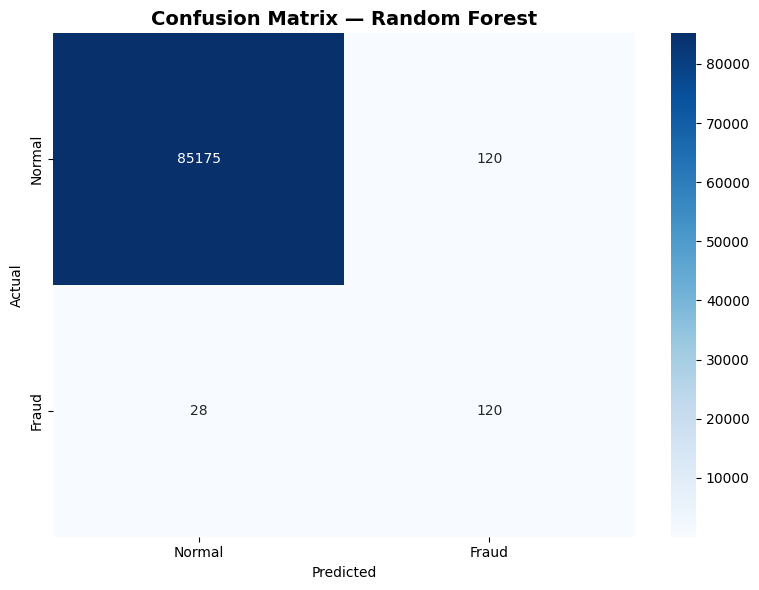

True Negatives:  85175
False Positives: 120
False Negatives: 28
True Positives:  120

Fraud catch rate: 81.1%
False alarm rate: 0.14%


In [3]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])

plt.title('Confusion Matrix — Random Forest',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('notebooks/confusion_matrix_rf.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nFraud catch rate: {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate: {fp/(fp+tn)*100:.2f}%")

In [4]:
from xgboost import XGBClassifier

mlflow.set_experiment("fraud_detection")

with mlflow.start_run(run_name="xgboost_v1"):

    xgb_model = XGBClassifier(         # more trees (was 100)
        n_estimators=200,              # shallower (was 6) → less overfit
        max_depth=4,                   #slower learning (was 0.1)
        learning_rate=0.05,            
        subsample=0.8,                 #use 80% of data per tree
        colsample_bytree=0.8,          # use 80% of features per tre
       min_child_weight=5,            ## minimum samples in leaf
       scale_pos_weight=1,           
        random_state=42,                            
        eval_metric='auc',
        verbosity=0
    )

    # Log parameters
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("subsample", 0.8)

    # Train
    print("Training XGBoost...")
    xgb_model.fit(X_train_bal, y_train_bal)
    print("Training done!")

    # Predict
    y_pred_xgb = xgb_model.predict(X_test)
    y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

    # Metrics
    auc  = roc_auc_score(y_test, y_prob_xgb)
    f1   = f1_score(y_test, y_pred_xgb)
    prec = precision_score(y_test, y_pred_xgb)
    rec  = recall_score(y_test, y_pred_xgb)

    # Log metrics
    mlflow.log_metric("auc_roc", auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)

    # Log model
    mlflow.sklearn.log_model(xgb_model, "model")

    print("\n" + "="*50)
    print("XGBOOST RESULTS")
    print("="*50)
    print(f"AUC-ROC:   {auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred_xgb,
          target_names=['Normal', 'Fraud']))

    xgb_run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID: {xgb_run_id}")

Training XGBoost...
Training done!


2026/06/09 11:31:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 11:31:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBOOST RESULTS
AUC-ROC:   0.9739
F1 Score:  0.3536
Precision: 0.2236
Recall:    0.8446

Detailed Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     85295
       Fraud       0.22      0.84      0.35       148

    accuracy                           0.99     85443
   macro avg       0.61      0.92      0.68     85443
weighted avg       1.00      0.99      1.00     85443


MLflow Run ID: a3606d7c2a864deeb5cd0ced85105a5b


In [5]:
X_train = np.load('data/processed/X_train_orig.npy')
y_train = np.load('data/processed/y_train_orig.npy')

print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Fraud in train: {(y_train==1).sum()}")
print(f"Normal in train: {(y_train==0).sum()}")

ratio = (y_train==0).sum() / (y_train==1).sum()
print(f"\nscale_pos_weight: {ratio:.1f}")

X_train: (199364, 31)
y_train: (199364,)
Fraud in train: 344
Normal in train: 199020

scale_pos_weight: 578.5


In [6]:
with mlflow.start_run(run_name="xgboost_no_smote"):

    # scale_pos_weight = normal/fraud ratio
    # tells XGBoost how imbalanced the data is
    ratio = (y_train == 0).sum() / (y_train == 1).sum()
    print(f"scale_pos_weight: {ratio:.1f}")

    xgb_final = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        scale_pos_weight=ratio,  # handles imbalance internally
        random_state=42,
        eval_metric='auc',
        verbosity=0
    )

    mlflow.log_param("model_type", "XGBoost_no_smote")
    mlflow.log_param("scale_pos_weight", ratio)
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("smote_applied", False)

    print("Training XGBoost without SMOTE...")
    # Use ORIGINAL imbalanced training data
    xgb_final.fit(X_train, y_train)
    print("Done!")

    y_pred_f = xgb_final.predict(X_test)
    y_prob_f = xgb_final.predict_proba(X_test)[:, 1]

    auc_f  = roc_auc_score(y_test, y_prob_f)
    f1_f   = f1_score(y_test, y_pred_f)
    prec_f = precision_score(y_test, y_pred_f)
    rec_f  = recall_score(y_test, y_pred_f)

    mlflow.log_metric("auc_roc", auc_f)
    mlflow.log_metric("f1_score", f1_f)
    mlflow.log_metric("precision", prec_f)
    mlflow.log_metric("recall", rec_f)
    mlflow.sklearn.log_model(xgb_final, "model")

    print("\n" + "="*50)
    print("XGBOOST WITHOUT SMOTE")
    print("="*50)
    print(f"AUC-ROC:   {auc_f:.4f}")
    print(f"F1 Score:  {f1_f:.4f}")
    print(f"Precision: {prec_f:.4f}")
    print(f"Recall:    {rec_f:.4f}")
    print(classification_report(y_test, y_pred_f,
          target_names=['Normal', 'Fraud']))

scale_pos_weight: 578.5
Training XGBoost without SMOTE...
Done!


2026/06/09 11:32:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 11:32:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



XGBOOST WITHOUT SMOTE
AUC-ROC:   0.9627
F1 Score:  0.8339
Precision: 0.8741
Recall:    0.7973
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     85295
       Fraud       0.87      0.80      0.83       148

    accuracy                           1.00     85443
   macro avg       0.94      0.90      0.92     85443
weighted avg       1.00      1.00      1.00     85443



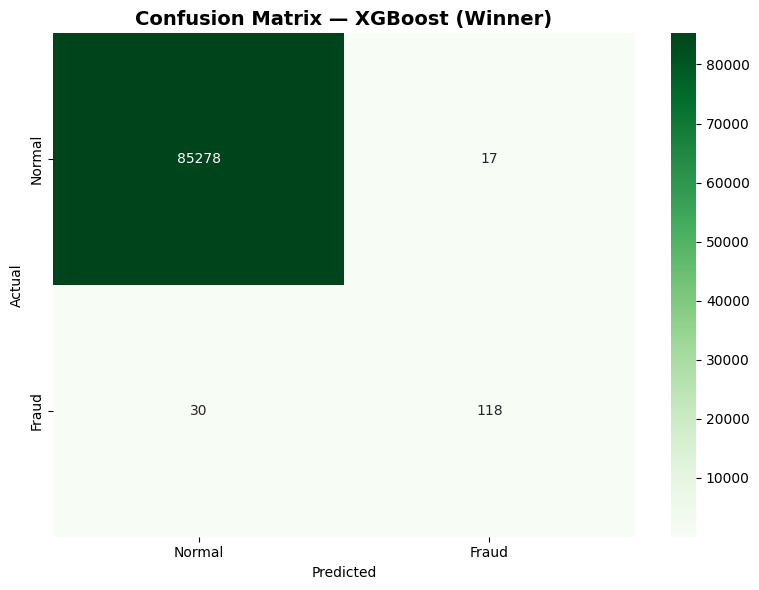

True Negatives:  85,278
False Positives: 17
False Negatives: 30
True Positives:  118

Fraud catch rate: 79.7%
False alarm rate: 0.020%


In [7]:
cm = confusion_matrix(y_test, y_pred_f)

plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=['Normal', 'Fraud'],
            yticklabels=['Normal', 'Fraud'])

plt.title('Confusion Matrix — XGBoost (Winner)',
          fontweight='bold', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('notebooks/confusion_matrix_xgb_final.png')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")
print(f"\nFraud catch rate: {tp/(tp+fn)*100:.1f}%")
print(f"False alarm rate: {fp/(fp+tn)*100:.3f}%")

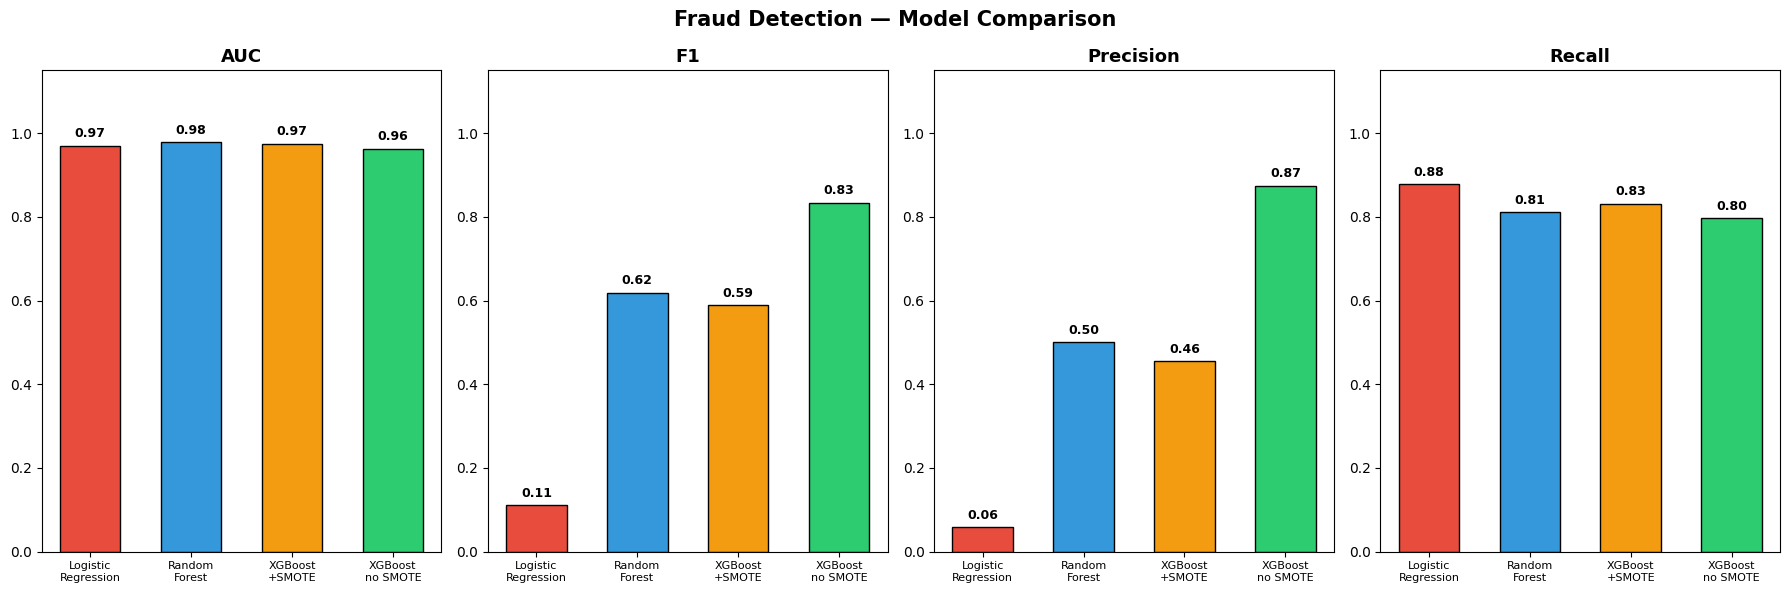

Chart saved!


In [8]:
results = {
    'Model': ['Logistic\nRegression',
              'Random\nForest',
              'XGBoost\n+SMOTE',
              'XGBoost\nno SMOTE'],
    'AUC':       [0.9701, 0.9783, 0.9749, 0.9627],
    'F1':        [0.1108, 0.6186, 0.5885, 0.8339],
    'Precision': [0.0591, 0.5000, 0.4556, 0.8741],
    'Recall':    [0.8784, 0.8108, 0.8311, 0.7973]
}

df_results = pd.DataFrame(results)

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
metrics = ['AUC', 'F1', 'Precision', 'Recall']
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(
        df_results['Model'],
        df_results[metric],
        color=colors,
        edgecolor='black',
        width=0.6
    )
    axes[i].set_title(metric, fontweight='bold', fontsize=13)
    axes[i].set_ylim(0, 1.15)
    axes[i].tick_params(axis='x', labelsize=8)

    for bar, val in zip(bars, df_results[metric]):
        axes[i].text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.2f}',
            ha='center',
            fontweight='bold',
            fontsize=9
        )

plt.suptitle('Fraud Detection — Model Comparison',
             fontweight='bold', fontsize=15)
plt.tight_layout()
plt.savefig('notebooks/final_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [10]:
import joblib

# Save winning model
joblib.dump(xgb_final, 'models/fraud_model_xgb.pkl')
print("✅ Winner model saved!")


✅ Winner model saved!
